# **🛒 E-Commerce Business Analysis Using SQL**

## 📌 Project Overview

This project analyzes an e-commerce dataset using SQL and Python to understand business performance, customer behavior, product trends, delivery efficiency, and revenue growth. The goal is to identify key insights and provide data-driven recommendations for business improvement.

## 🎯 Business Objectives
Analyze revenue trends over time
Identify top-performing product categories
Understand customer purchasing behavior
Evaluate delivery performance
Analyze payment methods
Identify top-performing sellers
Explore geographic sales distribution

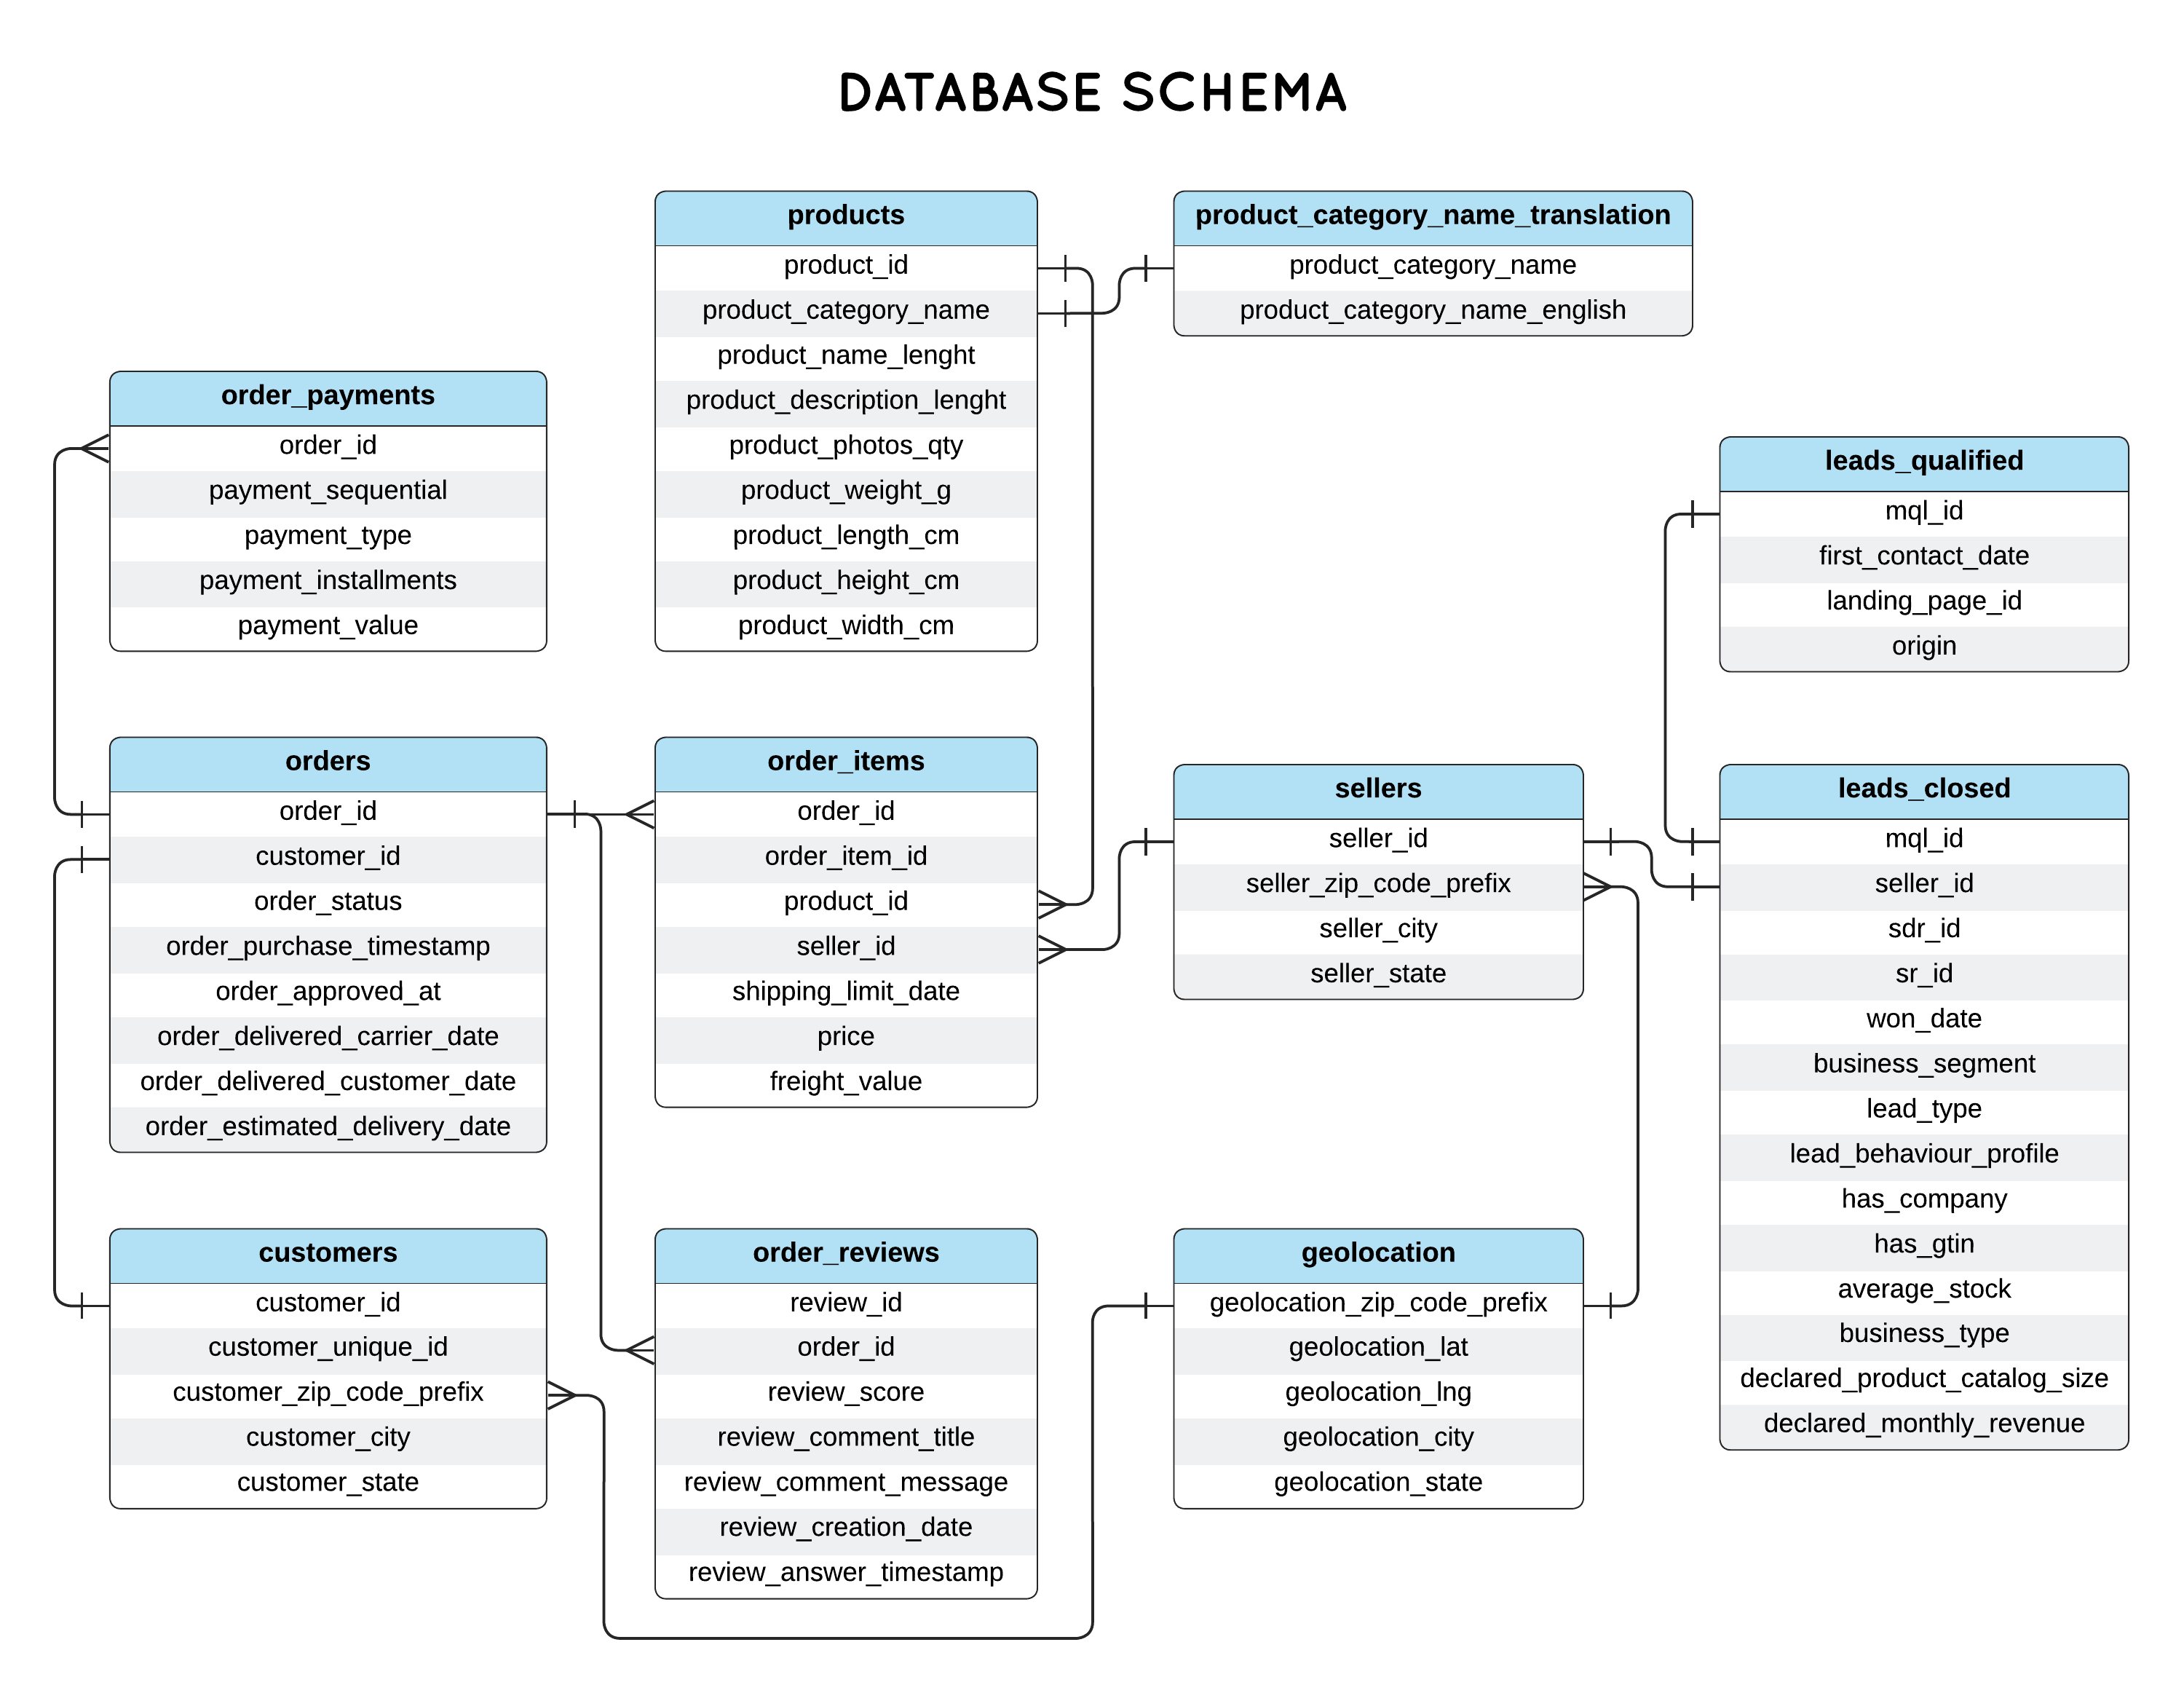

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/e-commerce-dataset-by-olist-as-an-sqlite-database/olist.sqlite


In [2]:
#Import Libraries
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

In [3]:
warnings.filterwarnings('ignore')

### Create Database Connection

In [4]:
url='/kaggle/input/e-commerce-dataset-by-olist-as-an-sqlite-database/olist.sqlite'

In [5]:
db_connection=sqlite3.connect(url)

### Helper Function for SQL Queries

In [6]:
def sql_query(q):
    return pd.read_sql_query(q,db_connection)

In [7]:
q='SELECT * FROM sqlite_master'

In [8]:
sql_query(q)

,type,name,tbl_name,rootpage,sql
0,table,product_category_name_translation,product_category_name_translation,2,"CREATE TABLE ""product_category_name_translatio..."
1,table,sellers,sellers,3,"CREATE TABLE ""sellers"" (\n""seller_id"" TEXT,\n ..."
2,table,customers,customers,48,"CREATE TABLE ""customers"" (\n""customer_id"" TEXT..."
3,table,geolocation,geolocation,2282,"CREATE TABLE ""geolocation"" (\n""geolocation_zip..."
4,table,order_items,order_items,12881,"CREATE TABLE ""order_items"" (\n""order_id"" TEXT,..."
5,table,order_payments,order_payments,16916,"CREATE TABLE ""order_payments"" (\n""order_id"" TE..."
6,table,order_reviews,order_reviews,18508,"CREATE TABLE ""order_reviews"" (\n""review_id"" TE..."
7,table,orders,orders,22174,"CREATE TABLE ""orders"" (\n""order_id"" TEXT,\n ""..."
8,table,products,products,26706,"CREATE TABLE ""products"" (\n""product_id"" TEXT,\..."
9,table,leads_qualified,leads_qualified,27283,"CREATE TABLE ""leads_qualified"" (\n""mql_id"" TEX..."


# 💰 Sales & Revenue Analysis
###   What is the total revenue and how does it change over time?

In [9]:
q='''SELECT * FROM order_payments'''

In [10]:
sql_query(q)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


In [11]:
q='''SELECT * FROM orders'''
df1=sql_query(q)
df1

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [12]:
q = '''
SELECT 
STRFTIME('%Y', ord.order_purchase_timestamp) AS Year,
substr('JanFebMarAprMayJunJulAugSepOctNovDec', 
    (strftime('%m', ord.order_purchase_timestamp) - 1) * 3 + 1, 3) AS Month,
ROUND(SUM(odpym.payment_value)) AS Total_Revenue
FROM order_payments odpym
INNER JOIN orders ord
ON odpym.order_id = ord.order_id
GROUP BY Year, Month
ORDER BY Year, STRFTIME('%m',ord.order_purchase_timestamp)
'''

In [13]:
df1=sql_query(q)
df1

,Year,Month,Total_Revenue
0,2016,Sep,252.0
1,2016,Oct,59090.0
2,2016,Dec,20.0
3,2017,Jan,138488.0
4,2017,Feb,291908.0
5,2017,Mar,449864.0
6,2017,Apr,417788.0
7,2017,May,592919.0
8,2017,Jun,511276.0
9,2017,Jul,592383.0


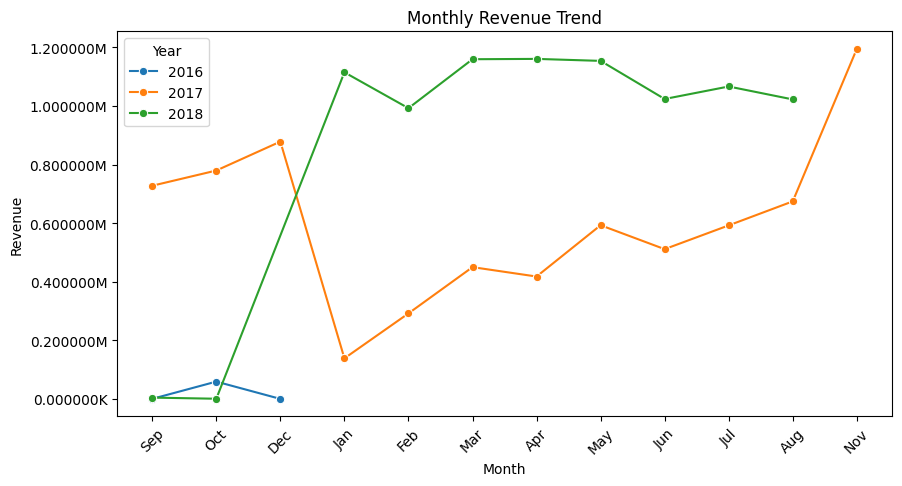

In [14]:
plt.figure(figsize=(10,5))
ax=sns.lineplot(data=df1, x="Month", y="Total_Revenue", hue="Year",marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
def format_k(x,pos):
    if x >=100000:
        return f'{x/1000000:1f}M'
    else:
        return f'{x/1000:0f}K'
ax.yaxis.set_major_formatter(mticker.FuncFormatter(format_k))
plt.show()

## Insight:
Revenue increased significantly from 2016 to 2017, indicating strong business growth and successful customer acquisition. Sales remained consistently high throughout 2018, suggesting market stability and sustained demand. The lower values observed in late 2018 are likely due to incomplete data rather than an actual decline in performance.

This trend shows that the business experienced rapid expansion followed by a period of stable growth.

# 🛍️ Product Performance Analysis

###   Which product categories generate the most sales

In [15]:
q='''SELECT * FROM products'''
df0=sql_query(q)
df0

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [16]:
q='''SELECT pcnt.product_category_name_english AS product_category,
SUM(oditem.price+oditem.freight_value) as Total_product_category_revenue
FROM product_category_name_translation pcnt
INNER JOIN  products pro
on pcnt.product_category_name =pro.product_category_name
INNER JOIN  order_items oditem
on
pro.product_id = oditem.product_id
GROUP BY product_category
ORDER BY Total_product_category_revenue desc
limit 15
'''


In [17]:
df2=sql_query(q)
df2

,product_category,Total_product_category_revenue
0,health_beauty,1441248.07
1,watches_gifts,1305541.61
2,bed_bath_table,1241681.72
3,sports_leisure,1156656.48
4,computers_accessories,1059272.40
5,furniture_decor,902511.79
6,housewares,778397.77
7,cool_stuff,719329.95
8,auto,685384.32
9,garden_tools,584219.21


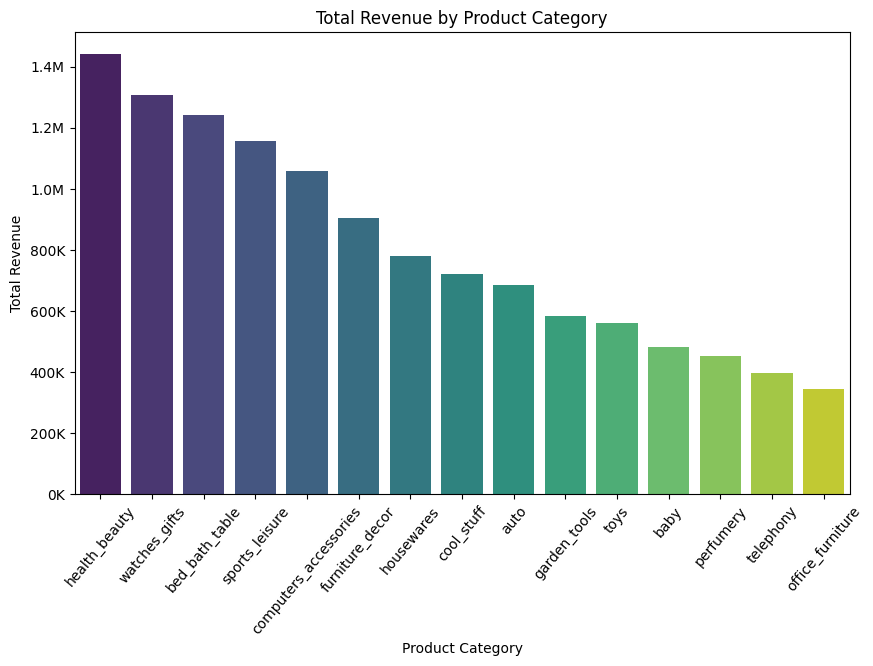

In [18]:
plt.figure(figsize=(10,6))
ax = sns.barplot(x=df2["product_category"],
                 y=df2["Total_product_category_revenue"],palette="viridis")
plt.xticks(rotation=50)
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.title("Total Revenue by Product Category")

def format_k(x, pos):
    if x >= 1000000:
        return f'{x/1000000:.1f}M'
    else:
        return f'{x/1000:.0f}K'

ax.yaxis.set_major_formatter(mticker.FuncFormatter(format_k))
plt.show()


## Insight:

The Health & Beauty category generated the highest revenue (1,441,248.07), followed by Watches & Gifts (1,305,541.61) and Bed Bath Table (1,241,681.72). Other strong-performing categories include Sports & Leisure (1,156,656.48) and Computers Accessories (1,059,272.40).

These results indicate that personal care, lifestyle, and home-related products are the main drivers of business revenue. The company may benefit from expanding these high-performing categories.

# 👥 Customer Analysis

###   How many unique customers are there and how often do they repeat purchases?

In [19]:
q='''SELECT * FROM customers'''
ds=sql_query(q)
ds

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


In [20]:
q='''SELECT
    COUNT(DISTINCT customer_unique_id) AS total_customers,

    SUM(
        CASE 
            WHEN order_count > 1 THEN 1 
            ELSE 0 
        END
    ) AS repeat_customers,

    ROUND(
        100.0 * SUM(CASE WHEN order_count > 1 THEN 1 ELSE 0 END)
        / COUNT(DISTINCT customer_unique_id),
        2
    ) AS customer_repeat_rate_percentage

FROM (
    SELECT 
        cus.customer_unique_id,
        COUNT(ord.order_id) AS order_count
    FROM customers cus
    INNER JOIN orders ord
        ON cus.customer_id = ord.customer_id
    GROUP BY cus.customer_unique_id
) t'''

In [21]:
df3=sql_query(q)
df3

,total_customers,repeat_customers,customer_repeat_rate_percentage
0,96096,2997,3.12


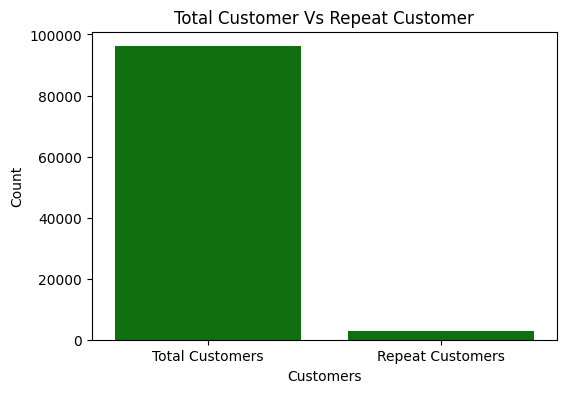

In [22]:
df=pd.DataFrame({
    "Customers":["Total Customers","Repeat Customers"],
    "Count":[96096,2997]
})
plt.figure(figsize=(6,4))
sns.barplot(data=df,x="Customers", y="Count",color="green")
plt.title("Total Customer Vs Repeat Customer")
plt.show()

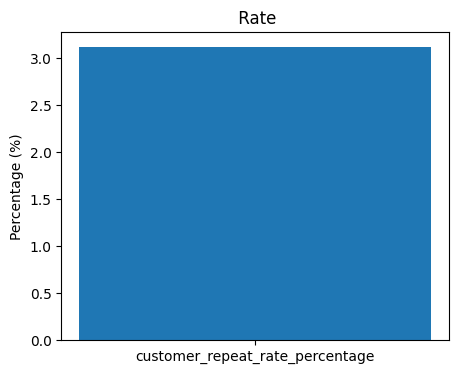

In [23]:
plt.figure(figsize=(5,4))
plt.bar(df3["customer_repeat_rate_percentage"].name,df3["customer_repeat_rate_percentage"].values)
plt.ylabel("Percentage (%)")
plt.title(" Rate")
plt.show()

## Insight:

The dataset contains 96,096 total customers, of which 2,997 customers made repeat purchases. This results in a repeat customer rate of 3.12%, indicating that most customers purchase only once.

This low repeat rate suggests that customer retention is a key area for improvement. The business may benefit from loyalty programs, discounts, or personalized marketing strategies.

# 🚚Delivery Performance

###  What is the average delivery time and how many orders are delayed?

In [24]:
q3='''SELECT * FROM orders'''

In [25]:
sql_query(q3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [26]:
q ='''SELECT Round(Avg(JULIANDAY(order_delivered_customer_date)-JULIANDAY(order_purchase_timestamp)),2) as Average_Delivery_Time,
      COUNT(CASE WHEN order_delivered_customer_date > order_estimated_delivery_date THEN "delay" END) AS Delay_Orders
      FROM orders
'''

In [27]:
df4=sql_query(q)
df4

,Average_Delivery_Time,Delay_Orders
0,12.56,7827


## Insight:

The average delivery time is approximately 12.56 days from purchase to delivery. Additionally, 7,827 orders were delivered later than the estimated delivery date.

This indicates that while most deliveries are completed successfully, there are notable delays affecting customer satisfaction. Improving logistics efficiency could enhance customer experience and retention.

# 💳 Payments Analysis
### Which payment types are most used and what is the average order value?


In [28]:
q3='''SELECT * FROM order_payments'''
sql_query(q3)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


In [29]:
q='''SELECT payment_type AS payment_mode_used,
COUNT(*) AS usage_count,
ROUND(Avg(payment_value),2) as average_payment_value
FROM order_payments
GROUP BY payment_mode_used
HAVING average_payment_value > 1
'''

In [30]:
df5=sql_query(q)
df5

,payment_mode_used,usage_count,average_payment_value
0,boleto,19784,145.03
1,credit_card,76795,163.32
2,debit_card,1529,142.57
3,voucher,5775,65.70


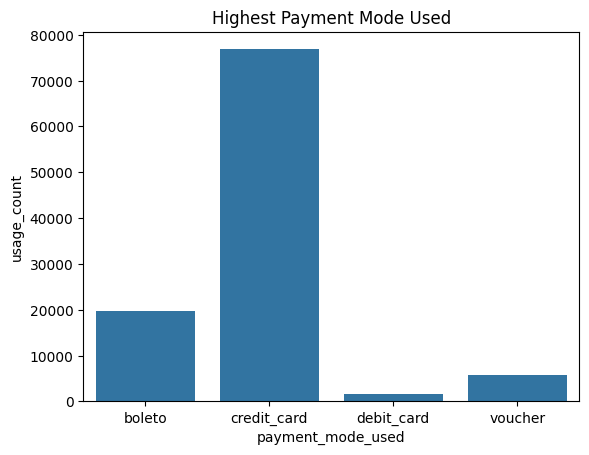

In [31]:
sns.barplot(x=df5['payment_mode_used'],y=df5['usage_count'])
plt.title("Highest Payment Mode Used")
plt.show()

## Insight:

Credit card is the most frequently used payment method and also generates the highest revenue. Customers spend an average of 163 per transaction when using credit cards.

This suggests that customers prefer convenient digital payment methods, and encouraging credit card usage may help increase revenu

# 🏪 Sellers Performance

### Which sellers perform best in terms of revenue and number of orders

In [32]:
q='''SELECT * FROM order_items'''
sql_query(q)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [33]:
q='''With top_seller as(SELECT orditm.seller_id AS seller_id,count(*) AS no_of_orders,
     SUM(orditm.price+orditm.freight_value) AS Total_revenue ,
     RANK() OVER(ORDER BY SUM(orditm.price+orditm.freight_value) Desc) AS Ranking
     FROM order_items orditm
     GROUP BY seller_id)
     SELECT seller_id, no_of_orders,Total_revenue FROM top_seller
     where Ranking <11
     '''

In [34]:
df6=sql_query(q)
df6

,seller_id,no_of_orders,Total_revenue
0,4869f7a5dfa277a7dca6462dcf3b52b2,1156,249640.70
1,7c67e1448b00f6e969d365cea6b010ab,1364,239536.44
2,53243585a1d6dc2643021fd1853d8905,410,235856.68
3,4a3ca9315b744ce9f8e9374361493884,1987,235539.96
4,fa1c13f2614d7b5c4749cbc52fecda94,586,204084.73
5,da8622b14eb17ae2831f4ac5b9dab84a,1551,185192.32
6,7e93a43ef30c4f03f38b393420bc753a,340,182754.05
7,1025f0e2d44d7041d6cf58b6550e0bfa,1428,172860.69
8,7a67c85e85bb2ce8582c35f2203ad736,1171,162648.38
9,955fee9216a65b617aa5c0531780ce60,1499,160602.68


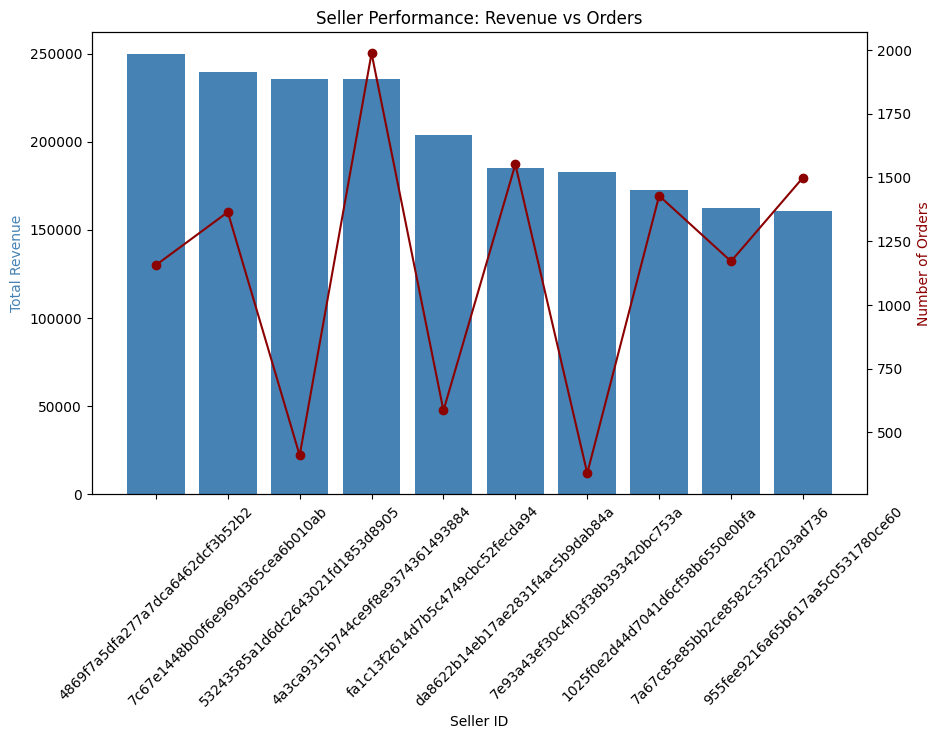

In [35]:
df = df6.sort_values(by="Total_revenue", ascending=False)

fig, ax1 = plt.subplots(figsize=(10,6))

ax1.bar(df6["seller_id"], df6["Total_revenue"], color='steelblue')
ax1.set_ylabel("Total Revenue", color='steelblue')
ax1.set_xlabel("Seller ID")
plt.xticks(rotation=45)

ax2 = ax1.twinx()
ax2.plot(df6["seller_id"], df6["no_of_orders"], color='darkred', marker='o')
ax2.set_ylabel("Number of Orders", color='darkred')

plt.title("Seller Performance: Revenue vs Orders")
plt.show()

# Insight:
Seller 4869f7a5dfa277a7dca6462dcf3b52b2 generated the highest revenue (249,640.70) from 1,156 orders. Seller 7c67e1448b00f6e969d365cea6b010ab generated the second highest revenue (239,536.44) from 1,364 orders.

Interestingly, seller 4a3ca9315b744ce9f8e9374361493884 processed the highest number of orders (1,987) but ranked lower in revenue. This indicates that higher order volume does not always result in higher revenue, suggesting differences in product pricing.

# 🌍 Geographic Analysis
###  Which cities generate the most orders and revenue?

In [36]:
q='''SELECT * FROM customers'''
sql_query(q)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


In [37]:
q='''With cities as(SELECT c.customer_city as Cities,ROUND(SUM(op.payment_value)) AS Total_revenue,
     COUNT(Distinct o.order_id) AS  No_of_orders,
     RANK()OVER(ORDER BY SUM(op.payment_value) desc) As Ranks
     FROM customers c
     
     INNER JOIN orders o
     ON
     c.customer_id = o.customer_id
     INNER JOIN order_payments op
     ON
     o.order_id=op.order_id
     GROUP BY customer_city
     )
     SELECT Cities,No_of_orders,Total_revenue FROM cities
     WHERE Ranks < 11'''


In [38]:
df7=sql_query(q)
df7

,Cities,No_of_orders,Total_revenue
0,sao paulo,15540,2203373.0
1,rio de janeiro,6882,1161927.0
2,belo horizonte,2773,421765.0
3,brasilia,2131,354217.0
4,curitiba,1521,247392.0
5,porto alegre,1379,224731.0
6,salvador,1245,218071.0
7,campinas,1444,216248.0
8,guarulhos,1189,165122.0
9,niteroi,849,139997.0


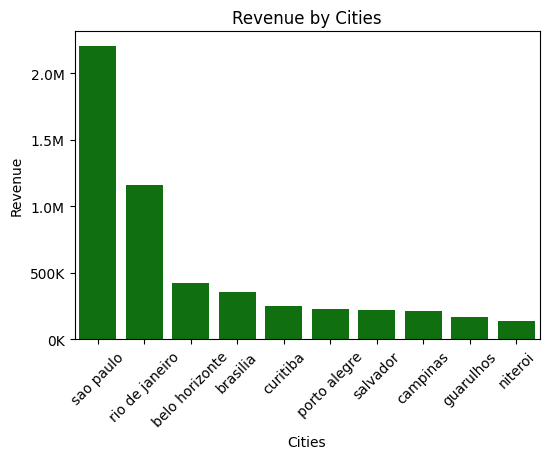

In [39]:
plt.figure(figsize=(6,4))
ax=sns.barplot(data=df7,x="Cities", y="Total_revenue",color="green")
plt.xticks(rotation=45)
plt.xlabel("Cities")
plt.ylabel("Revenue")
plt.title("Revenue by Cities")
def format_k(x, pos):
    if x >= 1000000:
        return f'{x/1000000:.1f}M'
    else:
        return f'{x/1000:.0f}K'

ax.yaxis.set_major_formatter(mticker.FuncFormatter(format_k))
plt.show()

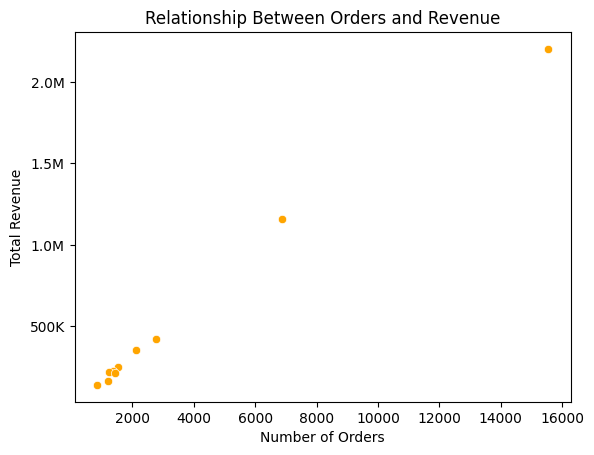

In [40]:
ax =sns.scatterplot(data=df7, x="No_of_orders", y="Total_revenue",color="orange")
plt.title("Relationship Between Orders and Revenue")
plt.xlabel("Number of Orders")
plt.ylabel("Total Revenue")
def formate_k(x,pos):
    if x >=1000000:
        return f'{x/100000:.1f}M'
    else:
        return f'{x/1000:.0f}K'
ax.yaxis.set_major_formatter(mticker.FuncFormatter(format_k))
plt.show()

# Insight:
São Paulo generated the highest number of orders (15,540) and the highest revenue (2.20M). Rio de Janeiro followed with 6,882 orders and 1.16M revenue. Other cities such as Belo Horizonte and Brasilia contributed moderately.

This indicates that revenue is concentrated in major cities, suggesting opportunities for expansion into smaller cities and regions.

# 📦 Order Behavior Analysis
### What is the average number of items per order?


In [41]:
q='''SELECT * FROM order_items'''
sql_query(q)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [42]:
q='''SELECT 
     COUNT(distinct od.order_id) AS total_order,
     COUNT(od.order_id) AS total_item,
     (COUNT(od.order_id)/COUNT(distinct od.order_id)) AS avg_number_of_item_per_order
     FROM order_items od
'''

In [43]:
df8=sql_query(q)
df8

,total_order,total_item,avg_number_of_item_per_order
0,98666,112650,1


# Insight:
On average, customers purchase 1.14 items per order, indicating that most customers buy only one product per order. This suggests an opportunity to increase order value through bundling and cross-selling strategies

# 📦 Order Delivery Performance

In [44]:
q='''SELECT * FROM ORDERS
'''
sql_query(q)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [45]:
q='''SELECT
COUNT(DISTINCT(od.order_id)) AS Total_Orders,
COUNT(DISTINCT CASE WHEN od.order_status == "delivered" THEN od.order_id END) AS Delivered_Orders,
COUNT(DISTINCT CASE WHEN od.order_status NOT IN ("delivered")THEN od.order_id END) AS Undeliver_Orders
FROM ORDERS od
'''
df=sql_query(q)
df

,Total_Orders,Delivered_Orders,Undeliver_Orders
0,99441,96478,2963


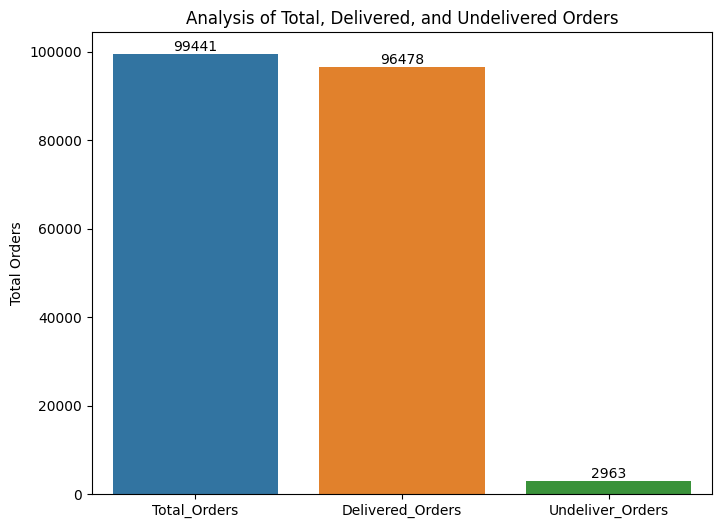

In [46]:
plt.figure(figsize=(8,6))
ax = sns.barplot(df)
plt.title("Analysis of Total, Delivered, and Undelivered Orders")
plt.ylabel("Total Orders")
for container in ax.containers:
    ax.bar_label(container)
plt.show()

# Insight:

Out of 99,441 total orders, 96,748 were successfully delivered, while 2,693 orders were not delivered. This indicates a strong delivery performance, with only a small percentage of orders facing delivery issues

# 📈 Leads & Conversion Analysis
### What is the conversion rate from leads to closed deals?


In [47]:
q='''SELECT * FROM leads_qualified'''
sql_query(q)

,mql_id,first_contact_date,landing_page_id,origin
0,dac32acd4db4c29c230538b72f8dd87d,2018-02-01,88740e65d5d6b056e0cda098e1ea6313,social
1,8c18d1de7f67e60dbd64e3c07d7e9d5d,2017-10-20,007f9098284a86ee80ddeb25d53e0af8,paid_search
2,b4bc852d233dfefc5131f593b538befa,2018-03-22,a7982125ff7aa3b2054c6e44f9d28522,organic_search
3,6be030b81c75970747525b843c1ef4f8,2018-01-22,d45d558f0daeecf3cccdffe3c59684aa,email
4,5420aad7fec3549a85876ba1c529bd84,2018-02-21,b48ec5f3b04e9068441002a19df93c6c,organic_search
...,...,...,...,...
7995,feaba3ffcd2ff97501696c7f9a42f41c,2018-05-22,e42a14209c69c3e9cc6b042620465f12,paid_search
7996,a79cb53cd009ab92e0143b92baa2407b,2018-03-27,c494978688ccf66ad9fad3d6a3338c22,paid_search
7997,68f049a23ab109c6a0f6989bb9a02994,2017-08-27,b48ec5f3b04e9068441002a19df93c6c,organic_search
7998,4f8c96e2509b984329044c6682c88ee9,2017-10-06,a56671a54260a44923d32c2f08fad39c,organic_search


In [48]:
q='''SELECT * FROM leads_closed'''
sql_query(q)

,mql_id,seller_id,sdr_id,sr_id,won_date,business_segment,lead_type,lead_behaviour_profile,has_company,has_gtin,average_stock,business_type,declared_product_catalog_size,declared_monthly_revenue
0,5420aad7fec3549a85876ba1c529bd84,2c43fb513632d29b3b58df74816f1b06,a8387c01a09e99ce014107505b92388c,4ef15afb4b2723d8f3d81e51ec7afefe,2018-02-26 19:58:54,pet,online_medium,cat,NaN,NaN,None,reseller,NaN,0.0
1,a555fb36b9368110ede0f043dfc3b9a0,bbb7d7893a450660432ea6652310ebb7,09285259593c61296eef10c734121d5b,d3d1e91a157ea7f90548eef82f1955e3,2018-05-08 20:17:59,car_accessories,industry,eagle,NaN,NaN,None,reseller,NaN,0.0
2,327174d3648a2d047e8940d7d15204ca,612170e34b97004b3ba37eae81836b4c,b90f87164b5f8c2cfa5c8572834dbe3f,6565aa9ce3178a5caf6171827af3a9ba,2018-06-05 17:27:23,home_appliances,online_big,cat,NaN,NaN,None,reseller,NaN,0.0
3,f5fee8f7da74f4887f5bcae2bafb6dd6,21e1781e36faf92725dde4730a88ca0f,56bf83c4bb35763a51c2baab501b4c67,d3d1e91a157ea7f90548eef82f1955e3,2018-01-17 13:51:03,food_drink,online_small,None,NaN,NaN,None,reseller,NaN,0.0
4,ffe640179b554e295c167a2f6be528e0,ed8cb7b190ceb6067227478e48cf8dde,4b339f9567d060bcea4f5136b9f5949e,d3d1e91a157ea7f90548eef82f1955e3,2018-07-03 20:17:45,home_appliances,industry,wolf,NaN,NaN,None,manufacturer,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
837,df9a2abe2ad3f2d8758b675ac8331ecf,bfcc27719640628da877db48b672b169,45749fb708130f78d0db07d8d80f030b,a8387c01a09e99ce014107505b92388c,2018-08-01 20:22:31,home_decor,offline,cat,NaN,NaN,None,reseller,NaN,0.0
838,8723201570415eb23b4f095d8c20a27c,4a82eab98441aeb64566e2776c1fb2b6,370c9f455f93a9a96cbe9bea48e70033,4b339f9567d060bcea4f5136b9f5949e,2018-09-27 18:58:41,construction_tools_house_garden,online_big,wolf,NaN,NaN,None,reseller,132.0,200000.0
839,2e57665b8faf05c967a801eb5aedfa0a,55031883943971ca22db6894574cfe2c,370c9f455f93a9a96cbe9bea48e70033,a8387c01a09e99ce014107505b92388c,2018-06-06 20:15:26,computers,online_medium,wolf,NaN,NaN,None,reseller,NaN,0.0
840,40955be51cc85c5a5a6cdd12b19e9f10,c0e933c238e41f0cd459d6025ee9b364,068066e24f0c643eb1d089c7dd20cd73,d3d1e91a157ea7f90548eef82f1955e3,2018-03-06 15:52:23,pet,online_beginner,cat,NaN,NaN,None,reseller,NaN,0.0


In [49]:
q9='''
WITH leads AS(select count(DISTINCT lc.mql_id) AS closed_deal_leads, 
     COUNT(DISTINCT ld.mql_id) AS Total_qualified_leads
     FROM leads_qualified ld
     LEFT JOIN leads_closed lc
     ON
     ld.mql_id = lc.mql_id)
SELECT Total_qualified_leads,closed_deal_leads,
(closed_deal_leads* 1.0/Total_qualified_leads)*100 AS conversion_rate
        FROM leads  
'''

In [50]:
df9=sql_query(q9)
df9

,Total_qualified_leads,closed_deal_leads,conversion_rate
0,8000,842,10.525


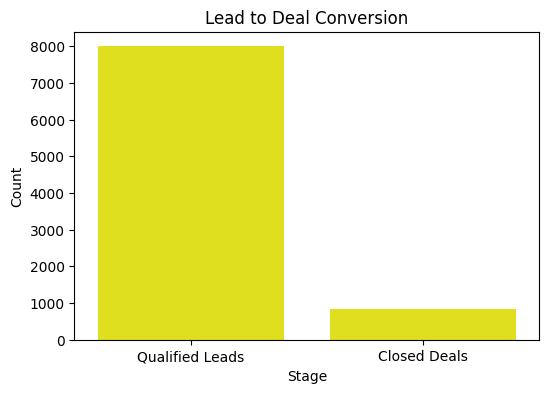

In [51]:
df = pd.DataFrame({
    "Stage": ["Qualified Leads", "Closed Deals"],
    "Count": [8000, 842]
})

plt.figure(figsize=(6,4))
sns.barplot(data=df, x="Stage", y="Count",color="yellow")
plt.title("Lead to Deal Conversion")
plt.show()

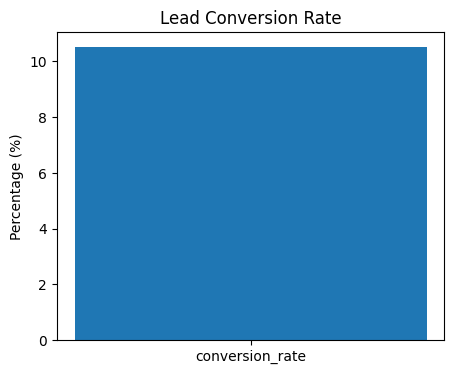

In [52]:
plt.figure(figsize=(5,4))
plt.bar(df9["conversion_rate"].name,df9["conversion_rate"].values)
plt.ylabel("Percentage (%)")
plt.title("Lead Conversion Rate")
plt.show()

## Insight:
Out of 8,000 qualified leads, 842 leads were successfully converted into closed deals, resulting in a conversion rate of 10.53%. This means that approximately 1 out of every 10 leads becomes a customer.

This metric helps evaluate the effectiveness of the sales process and lead quality..

# Conclusion:

This analysis provides valuable insights into the overall performance of the e-commerce business. The company experienced strong revenue growth, with lifestyle and personal care products driving the majority of sales. Major cities contribute the most revenue, indicating a concentration of demand in urban areas.

However, several areas require improvement. Customer retention is relatively low, with only 3.12% repeat customers. Delivery delays also impact customer satisfaction, and most orders contain only one item, limiting revenue potential.

To improve performance, the business should focus on enhancing customer retention strategies, improving delivery logistics, expanding into new geographic regions, and encouraging multi-item purchases. Implementing these strategies can help increase revenue, improve customer satisfaction, and support long-term business growth.